# 00685L 單日跌幅統計 (2017-03-30 至今)

統計 00685L 從掛牌以來的**單日跌幅事件**（今日 close 相對昨日 close 的下跌幅度）。

## 定義

- **單日跌幅事件**：某日 `close` < 前一日 `close`，跌幅 = `(prev_close - close) / prev_close × 100%`
- **原始金額** = 事件當日的**前一日 close**（下跌前的價位）
- **反彈天數** = 從事件當日起算、`close` 首次重回 ≥ 原始金額，其間的**交易日數**
- **區間**：0-5% / 5-10% / 10-15% / 15-20% / 20%+ （20% 以上額外列出但不納入主統計）

## 資料處理

- 使用 `data/adjusted/00685L.csv`（分割還原後）—— 若用 raw 分割日會出現 -96% 假跌幅
- 反彈天數用交易日（週末/假日不算）
- 若某事件至今仍未反彈，會另外列出、不計入平均

## 統計項目

1. **每年 × 每區間的事件次數**（pivot table + heatmap + 堆疊 bar chart）
2. **5-10、10-15、15-20 三區間各自**：
   - 總事件數
   - 平均反彈天數
   - **反彈天數最久的前三大 events**（peak 日 / 跌幅 / 反彈日 / 天數）
3. 未反彈事件（仍卡在原始金額之下）列表


## 1. 環境設定與資料載入

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
project_root = _cwd.parent if _cwd.name == 'notebooks' else _cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei", "Microsoft YaHei", "PingFang TC",
    "Noto Sans TC", "SimHei", "Arial",
]
matplotlib.rcParams["axes.unicode_minus"] = False

adjusted_path = project_root / "data" / "adjusted" / "00685L.csv"
df = pd.read_csv(adjusted_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(f"筆數: {len(df)}, 期間: {df['date'].iloc[0].date()} ~ {df['date'].iloc[-1].date()}")
df.head()


筆數: 2220, 期間: 2017-03-30 ~ 2026-07-13


,date,close
0,2017-03-30,0.413333
1,2017-03-31,0.411667
2,2017-04-05,0.418750
3,2017-04-06,0.415000
4,2017-04-07,0.412083


## 2. 計算每日跌幅、蒐集下跌事件

In [2]:
df['prev_close'] = df['close'].shift(1)
df['change_pct'] = (df['close'] / df['prev_close'] - 1) * 100
df['drop_pct'] = -df['change_pct']  # 正值 = 跌幅

def bucket(drop_pct):
    if drop_pct <= 0:
        return None
    if drop_pct < 5:
        return '0-5'
    if drop_pct < 10:
        return '5-10'
    if drop_pct < 15:
        return '10-15'
    if drop_pct < 20:
        return '15-20'
    return '20+'

df['bucket'] = df['drop_pct'].apply(bucket)
down_days = df[df['drop_pct'] > 0].copy()
print(f"下跌交易日數: {len(down_days)}（佔比 {len(down_days) / (len(df) - 1) * 100:.1f}%）")
print("\n各區間下跌天數：")
print(down_days['bucket'].value_counts().reindex(['0-5', '5-10', '10-15', '15-20', '20+'], fill_value=0))


下跌交易日數: 943（佔比 42.5%）

各區間下跌天數：
bucket
0-5      894
5-10      41
10-15      5
15-20      3
20+        0
Name: count, dtype: int64


## 3. 計算每個下跌事件的反彈天數

In [3]:
close_values = df['close'].values
dates = df['date'].values

def find_recovery(drop_idx, baseline):
    """從 drop_idx 起算，找首日 close >= baseline 的 index，回傳 (recovery_idx, recovery_days)"""
    for j in range(drop_idx + 1, len(close_values)):
        if close_values[j] >= baseline:
            return j, j - drop_idx  # 交易日數
    return None, None

events = []
for i in df.index:
    drop = df.at[i, 'drop_pct']
    if pd.isna(drop) or drop <= 0:
        continue
    baseline = df.at[i, 'prev_close']
    rec_idx, rec_days = find_recovery(i, baseline)
    events.append({
        'drop_date': df.at[i, 'date'],
        'year': df.at[i, 'date'].year,
        'prev_close': baseline,
        'close': df.at[i, 'close'],
        'drop_pct': drop,
        'bucket': df.at[i, 'bucket'],
        'recovered': rec_idx is not None,
        'recovery_date': df.at[rec_idx, 'date'] if rec_idx is not None else pd.NaT,
        'recovery_days': rec_days,
    })

events_df = pd.DataFrame(events)
print(f"總下跌事件: {len(events_df)}")
print(f"已反彈: {events_df['recovered'].sum()} · 未反彈: {(~events_df['recovered']).sum()}")
events_df.head()


總下跌事件: 943
已反彈: 937 · 未反彈: 6


,drop_date,year,prev_close,close,drop_pct,bucket,recovered,recovery_date,recovery_days
0,2017-03-31,2017,0.413333,0.411667,0.403226,0-5,True,2017-04-05,1.0
1,2017-04-06,2017,0.418750,0.415000,0.895522,0-5,True,2017-05-02,17.0
2,2017-04-07,2017,0.415000,0.412083,0.702811,0-5,True,2017-04-26,13.0
3,2017-04-11,2017,0.413750,0.410833,0.704935,0-5,True,2017-04-26,11.0
4,2017-04-12,2017,0.410833,0.410000,0.202840,0-5,True,2017-04-13,1.0


## 4. 每年 × 每區間的事件次數

In [4]:
BUCKET_ORDER = ['0-5', '5-10', '10-15', '15-20', '20+']
yearly_counts = events_df.groupby(['year', 'bucket']).size().unstack(fill_value=0)
yearly_counts = yearly_counts.reindex(columns=BUCKET_ORDER, fill_value=0)
yearly_counts['Total'] = yearly_counts.sum(axis=1)
yearly_counts


bucket,0-5,5-10,10-15,15-20,20+,Total
year,,,,,,
2017,69,0,0,0,0,69
2018,107,1,0,1,0,109
2019,99,0,0,0,0,99
2020,82,10,2,0,0,94
2021,98,6,0,0,0,104
2022,100,8,0,0,0,108
2023,99,0,0,0,0,99
2024,97,7,0,1,0,105
2025,97,4,2,1,0,104


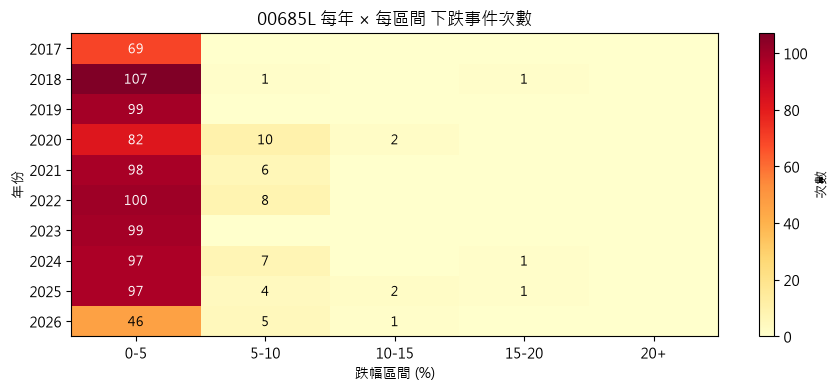

In [5]:
# Heatmap（顏色越深、次數越多）
data_for_heat = yearly_counts.drop(columns=['Total'])
fig, ax = plt.subplots(figsize=(9, max(4, len(data_for_heat) * 0.35)))
im = ax.imshow(data_for_heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(data_for_heat.columns)))
ax.set_xticklabels(data_for_heat.columns)
ax.set_yticks(range(len(data_for_heat.index)))
ax.set_yticklabels(data_for_heat.index)
ax.set_xlabel("跌幅區間 (%)")
ax.set_ylabel("年份")
ax.set_title("00685L 每年 × 每區間 下跌事件次數")
for i in range(data_for_heat.shape[0]):
    for j in range(data_for_heat.shape[1]):
        v = data_for_heat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha='center', va='center',
                    color='white' if v > data_for_heat.values.max() * 0.5 else 'black',
                    fontsize=9)
plt.colorbar(im, ax=ax, label="次數")
plt.tight_layout()
plt.show()


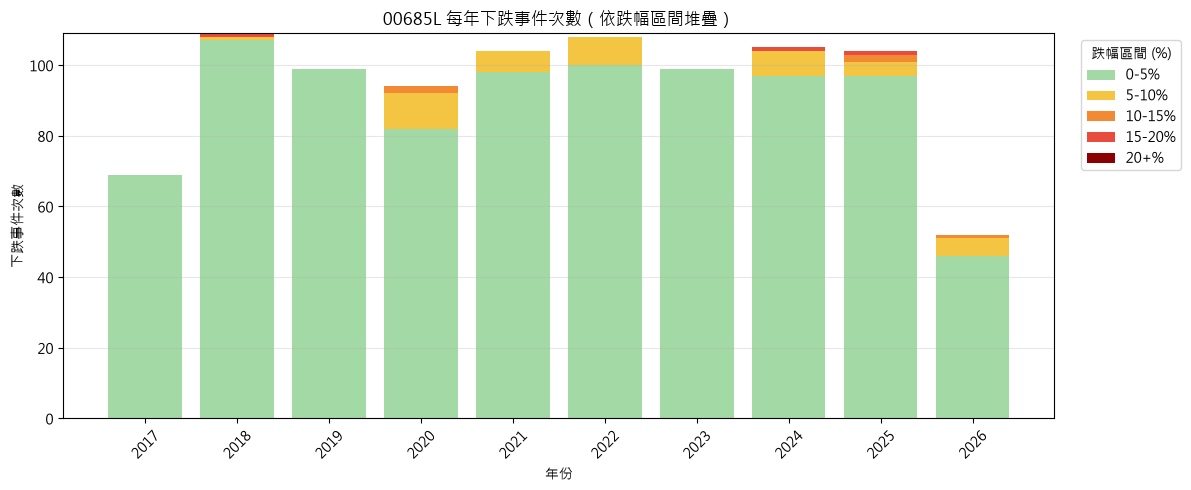

In [6]:
# 堆疊 bar chart（可以看每年下跌事件的組成）
bar_data = yearly_counts.drop(columns=['Total'])
fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(bar_data))
colors = {'0-5': '#a3d9a5', '5-10': '#f4c542', '10-15': '#f28a34', '15-20': '#e74c3c', '20+': '#8b0000'}
for b in BUCKET_ORDER:
    vals = bar_data[b].values
    ax.bar(bar_data.index.astype(str), vals, bottom=bottom, label=f"{b}%", color=colors[b])
    bottom += vals
ax.set_xlabel("年份")
ax.set_ylabel("下跌事件次數")
ax.set_title("00685L 每年下跌事件次數（依跌幅區間堆疊）")
ax.legend(title="跌幅區間 (%)", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. 5-10 / 10-15 / 15-20 三區間：平均反彈天數

In [7]:
FOCUS_BUCKETS = ['5-10', '10-15', '15-20']

summary_rows = []
for b in FOCUS_BUCKETS:
    sub = events_df[events_df['bucket'] == b]
    recovered = sub[sub['recovered']]
    not_rec = sub[~sub['recovered']]
    summary_rows.append({
        '區間 (%)': b,
        '總事件數': len(sub),
        '已反彈事件': len(recovered),
        '未反彈事件': len(not_rec),
        '平均反彈交易日': round(recovered['recovery_days'].mean(), 1) if len(recovered) > 0 else None,
        '中位數反彈交易日': int(recovered['recovery_days'].median()) if len(recovered) > 0 else None,
        '最短': int(recovered['recovery_days'].min()) if len(recovered) > 0 else None,
        '最長': int(recovered['recovery_days'].max()) if len(recovered) > 0 else None,
    })

bucket_summary_df = pd.DataFrame(summary_rows)
bucket_summary_df


,區間 (%),總事件數,已反彈事件,未反彈事件,平均反彈交易日,中位數反彈交易日,最短,最長
0,5-10,41,41,0,29.5,14,1,289
1,10-15,5,5,0,23.2,3,1,107
2,15-20,3,3,0,45.7,28,7,102


## 6. 各區間：反彈天數最久的前三大 events

In [8]:
for b in FOCUS_BUCKETS:
    sub = events_df[(events_df['bucket'] == b) & events_df['recovered']].copy()
    if len(sub) == 0:
        print(f"\n=== {b}% 區間 ===  (無已反彈事件)")
        continue
    top3 = sub.nlargest(3, 'recovery_days').copy()
    top3['drop_date'] = top3['drop_date'].dt.strftime('%Y-%m-%d')
    top3['recovery_date'] = top3['recovery_date'].dt.strftime('%Y-%m-%d')
    top3['drop_pct'] = top3['drop_pct'].round(2)
    top3['prev_close'] = top3['prev_close'].round(4)
    top3['close'] = top3['close'].round(4)
    print(f"\n=== {b}% 區間 · 前 3 大反彈天數 ===")
    print(top3[['drop_date', 'prev_close', 'close', 'drop_pct',
                'recovery_date', 'recovery_days']].to_string(index=False))



=== 5-10% 區間 · 前 3 大反彈天數 ===
 drop_date  prev_close  close  drop_pct recovery_date  recovery_days
2022-02-24      2.0612 1.9550      5.15    2023-06-13          289.0
2024-11-12      3.7667 3.5667      5.31    2025-08-11          181.0
2022-08-29      1.5963 1.5158      5.04    2023-01-30           99.0

=== 10-15% 區間 · 前 3 大反彈天數 ===
 drop_date  prev_close  close  drop_pct recovery_date  recovery_days
2020-01-30      0.7825 0.6988     10.70    2020-07-07          107.0
2020-03-19      0.4404 0.3850     12.58    2020-03-24            3.0
2025-04-08      2.3812 2.1104     11.37    2025-04-11            3.0

=== 15-20% 區間 · 前 3 大反彈天數 ===
 drop_date  prev_close  close  drop_pct recovery_date  recovery_days
2018-10-11      0.5396 0.4567     15.37    2019-03-19          102.0
2025-04-07      2.9750 2.3812     19.96    2025-05-16           28.0
2024-08-05      3.2708 2.6396     19.30    2024-08-14            7.0


## 7. 尚未反彈的事件（目前 close 仍 < 事件當日 prev_close）

In [9]:
not_recovered = events_df[~events_df['recovered']].copy()
if len(not_recovered) == 0:
    print("目前沒有未反彈的事件（所有下跌都已經 close 重回原始金額）。")
else:
    not_recovered['drop_date'] = not_recovered['drop_date'].dt.strftime('%Y-%m-%d')
    not_recovered['drop_pct'] = not_recovered['drop_pct'].round(2)
    not_recovered['prev_close'] = not_recovered['prev_close'].round(4)
    not_recovered['close'] = not_recovered['close'].round(4)
    # 只顯示跌幅 >= 5% 的（因為 0-5 太多、意義較小）
    significant = not_recovered[not_recovered['drop_pct'] >= 5]
    print(f"未反彈事件（跌幅 ≥ 5%）: {len(significant)} 筆")
    print(significant[['drop_date', 'bucket', 'prev_close', 'close', 'drop_pct']].to_string(index=False))


未反彈事件（跌幅 ≥ 5%）: 0 筆
Empty DataFrame
Columns: [drop_date, bucket, prev_close, close, drop_pct]
Index: []


## 8. 前三大天數視覺化（各區間並排 bar chart）

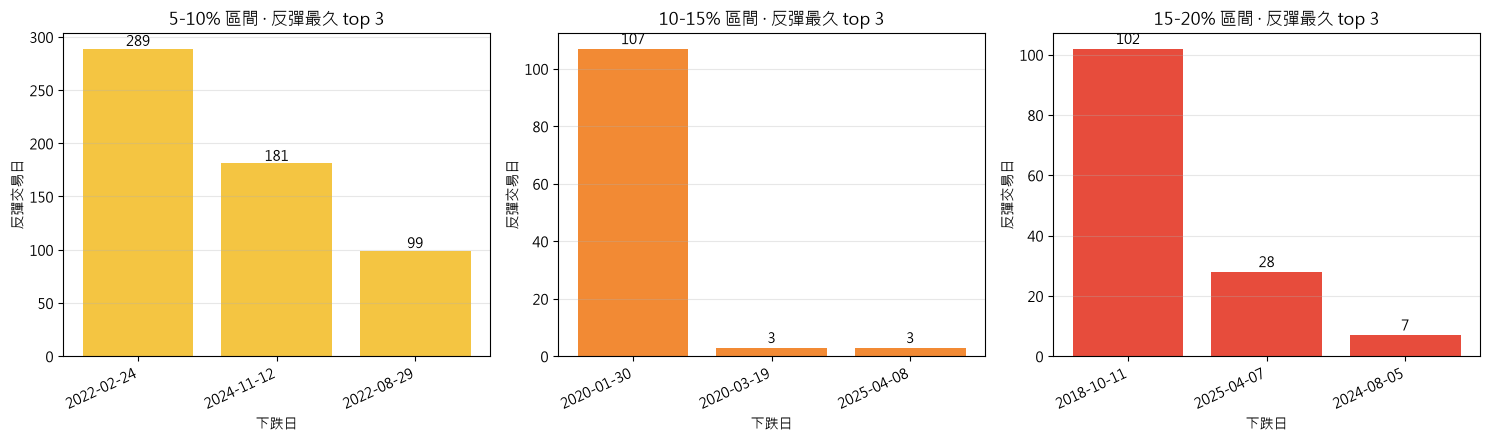

In [10]:
fig, axes = plt.subplots(1, len(FOCUS_BUCKETS), figsize=(15, 4.5), sharey=False)
if len(FOCUS_BUCKETS) == 1:
    axes = [axes]
color_map = {'5-10': '#f4c542', '10-15': '#f28a34', '15-20': '#e74c3c'}
for ax, b in zip(axes, FOCUS_BUCKETS):
    sub = events_df[(events_df['bucket'] == b) & events_df['recovered']]
    if len(sub) == 0:
        ax.text(0.5, 0.5, "無資料", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{b}% 區間")
        continue
    top3 = sub.nlargest(3, 'recovery_days')
    labels = [d.strftime('%Y-%m-%d') for d in top3['drop_date']]
    vals = top3['recovery_days'].values
    bars = ax.bar(labels, vals, color=color_map[b])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{int(v)}",
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{b}% 區間 · 反彈最久 top 3")
    ax.set_ylabel("反彈交易日")
    ax.set_xlabel("下跌日")
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 9. 細分 0-10% 區間內下跌事件次數（每 1% 一區）

把 0-10% 這一段細分為 10 個 1% 區間（0-1, 1-2, ..., 9-10），看每格分別發生多少次下跌事件。

**策略觀點**：既然歷史上下跌事件多數落在 0-10%、給時間都會反彈回原始金額，本金交易可著重在 0-10% 這個區間；10-20% 保留為額外加碼空間。

0-10% 區間內共 935 個下跌事件
   區間  次數 佔 0-10% 比例
 0-1% 403      43.1%
 1-2% 254      27.2%
 2-3% 139      14.9%
 3-4%  66       7.1%
 4-5%  32       3.4%
 5-6%  20       2.1%
 6-7%   5       0.5%
 7-8%   5       0.5%
 8-9%   7       0.7%
9-10%   4       0.4%


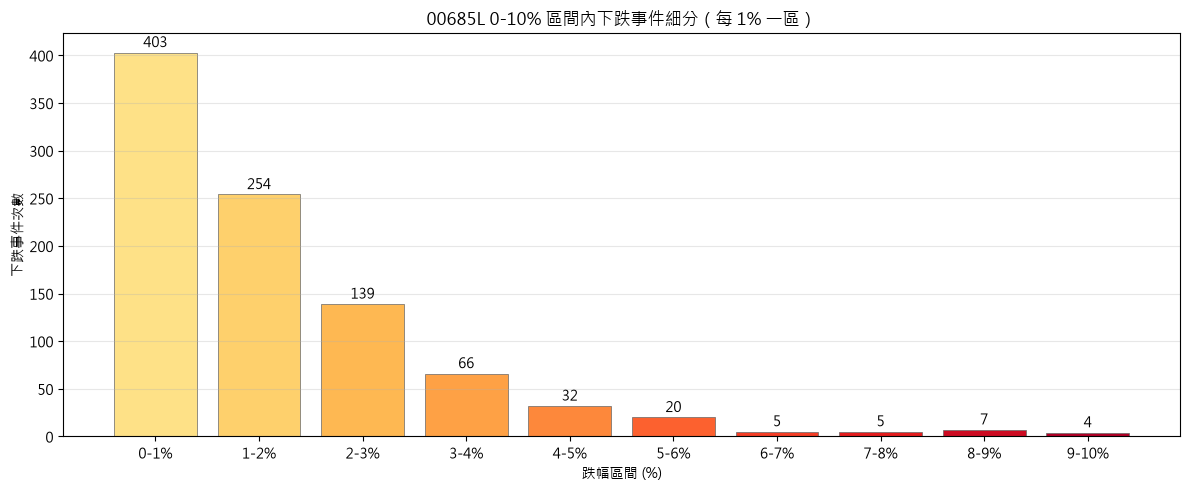

In [11]:
fine_events = events_df[(events_df['drop_pct'] > 0) & (events_df['drop_pct'] < 10)].copy()
fine_events['fine_bucket'] = fine_events['drop_pct'].astype(int)
fine_counts = fine_events['fine_bucket'].value_counts().reindex(range(10), fill_value=0).sort_index()
total = int(fine_counts.sum())

table = pd.DataFrame({
    '區間': [f'{i}-{i+1}%' for i in range(10)],
    '次數': fine_counts.values,
    '佔 0-10% 比例': [f'{v/total*100:.1f}%' if total > 0 else '-' for v in fine_counts.values],
})
print(f'0-10% 區間內共 {total} 個下跌事件')
print(table.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
labels = [f'{i}-{i+1}%' for i in range(10)]
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, 10))
bars = ax.bar(labels, fine_counts.values, color=colors, edgecolor='#666', linewidth=0.5)
for bar, v in zip(bars, fine_counts.values):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v + max(fine_counts.values) * 0.01,
                f'{int(v)}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('跌幅區間 (%)')
ax.set_ylabel('下跌事件次數')
ax.set_title('00685L 0-10% 區間內下跌事件細分（每 1% 一區）')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 觀察方向

跑完後可以看：

1. **哪一年下跌事件最多**：Heatmap 越紅代表該區間該年次數高
2. **極端跌幅事件**：15-20% 的次數應該很少（甚至沒有）；反之 0-5% 幾乎每年都很多
3. **反彈速度差異**：跌幅越大反彈越久嗎？（一般是的，但 00685L 是 2× 槓桿 ETF，波動大反彈也可能快）
4. **未反彈事件**：如果有出現且是 10% 以上、代表當下仍卡在該事件的原始金額之下
5. **前三大反彈天數**：可以看時間點是否對應到市場熊市（例如 2015、2018、2022 大跌）
